# 2. Hyperparameter tuning

This notebook examines UMAP and hdbscan hyperparameters. The goal in using these algorithms is to identify clusters of words that substantially represent the same "concept." Different parameters are tried, checked for coherence, and manually inspected.

Input:\
`data/ANES_2016_CLEANED.txt` : a tab-seperated file with `_clean` fields for every text response. 

Output:\
No output file. However, hyperparameters determined to result in coherent word clusters are retained for use in `3_NetworkExtraction.ipynb`. The replicabled parameters used are:
* seed = 42 (used as `random_state` in `UMAP()` function
* n_components = 35  (UMAP)
* min_cluster_size = 3 (hdbscan)
* min_samples = 2  (hdbscan)


In [1]:
# helpful packages
import pandas as pd
import itertools as it
import numpy as np

# language models
import spacy
from spacy.tokens import Doc
nlp = spacy.load('en_core_web_trf')

# language clustering
from gensim.models import KeyedVectors
import umap
import hdbscan
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import adjusted_rand_score
from sklearn.metrics import mutual_info_score

import os
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

# visualization
import matplotlib.pyplot as plt

# Load cleaned data

In [2]:
# read cleaned data
df = pd.read_csv('data/ANES_2016_CLEANED.txt', sep='\t')

print(f'Data includes {len(df)} observations on {len(df.columns)} variables.')
print(f'\nRecorded variables are:\n{", ".join(df.columns)}')

Data includes 4270 observations on 30 variables.

Recorded variables are:
V160001, V160001_orig, age, female, education, leftright, politicalinterest, politicalparticipation, TIPI_extraversion, TIPI_agreeableness, TIPI_conscientiousness, TIPI_emotionalstability, TIPI_openness, V161069, V161072, V161075, V161078, V161098, V161101, V161104, V161106, party_id, V161069_clean, V161072_clean, V161075_clean, V161078_clean, V161098_clean, V161101_clean, V161104_clean, V161106_clean


In [3]:
# Questions with free-response answers. 
text_qs = ['V161069', # PRE: Text- What is it that R likes about Democratic Pres cand
           'V161072', # PRE: Text- What is it that R dislikes about Democratic Pres cand
           'V161075', # PRE: Text- What is it that R likes about Republican Pres cand
           'V161078', # PRE: Text- What is it that R dislikes about Republican Pres cand
           'V161098', # PRE: Text- What does R like about Democratic party
           'V161101', # PRE: Text- What does R dislike about the Democratic party
           'V161104', # PRE: Text- What does R like about Republican party
           'V161106'  # PRE: Text- What does R dislike about the Republican party
          ]

In [4]:
# create spacy docs of each response
for q in text_qs:
    print(f'  Processing question {q}')
    df[f'{q}_doc'] = df[f'{q}_clean'].fillna('').apply(lambda x: nlp(x))
    
print('All text converted to SpaCy.')

  Processing question V161069
  Processing question V161072
  Processing question V161075
  Processing question V161078
  Processing question V161098
  Processing question V161101
  Processing question V161104
  Processing question V161106
All text converted to SpaCy.


# Word (node) extraction

In [5]:
# keep as nodes word that are these parts of speech:
keep_pos = ['ADJ', 'ADV', 'NOUN', 'PROPN', 'VERB']


raw_nodes = list()

for q in text_qs:
    docs = df[f'{q}_doc']

    for doc in docs:
        # nodes to keep (unclustered)
        for token in doc:
            if token.pos_ in keep_pos and token.lemma_ not in raw_nodes:
                raw_nodes.append(token.lemma_)
                
print(f'{len(raw_nodes)} words initially retained as nodes across all responses')

5365 words initially retained as nodes across all responses


### Convert to embeddings

In [6]:
# embeddings model
model = KeyedVectors.load_word2vec_format('../GoogleNews-vectors-negative300.bin', binary=True)

vecs = list() # embeddings for in-vocab words
kept = list() # words that have an embedding in vecs 
skipped = list() # out of vocab (dropped from analysis)

for word in raw_nodes:
    try:
        vector = model[word]
        vecs.append(vector) # save vector
        kept.append(word) # save word
    except:
        skipped.append(word) # out of vocab (after spell check correction)
    
word_embeddings = np.vstack(vecs)

w, n = word_embeddings.shape
print(f'{w} words embedded into {n}-dimensions.') # 4412 
print(f'{len(skipped)} words dropped as out of vocabulary.') # 953

4412 words embedded into 300-dimensions.
953 words dropped as out of vocabulary.


# Cluster word embeddings using UMap + hdbscan

In [7]:
def calc_coherence(words, word_embeddings, cluster_labels):
    # calculate intra-cluster coherence

    clusters = np.arange(0, max(cluster_labels), step=1)
    coherence_scores = np.zeros(len(clusters))

    # Note: "clusters" starts at 0. DON'T calc coherence for -1 "noise" cluster
    for cluster_id in clusters:
        
        # get indices belonging to this cluster
        indices = np.where(cluster_labels == cluster_id)[0]
        cluster_words = [words[i] for i in indices]
        cluster_vecs = word_embeddings[indices]

        if len(cluster_vecs) < 2:
            coherence_scores[cluster_id] = None  # can't compute pairwise for 1 word
            continue

        # mean pairwise cosine similarity
        sim_matrix = cosine_similarity(cluster_vecs)
        
        # upper triangle only (exclude self-similarity on diagonal)
        upper = sim_matrix[np.triu_indices_from(sim_matrix, k=1)]
        coherence_scores[cluster_id] = upper.mean()

    return coherence_scores

In [8]:
def run_clustering(n_components, min_cluster_size, min_samples, word_embeddings, seed=42):
    
    # reduce dimensionality
    reducer = umap.UMAP(n_components = n_components, random_state=seed, n_jobs=1) 
    embedding = reducer.fit_transform(word_embeddings)

    # cluster
    clusterer = hdbscan.HDBSCAN(min_cluster_size = min_cluster_size, 
                                min_samples = min_samples, 
                                prediction_data = True,
                                approx_min_span_tree=False)

    cluster_labels = clusterer.fit_predict(embedding)
    
    return cluster_labels

In [9]:
def check_hyper(kept, word_embeddings):
    n_components_range = np.arange(5, 51, 5)
    min_cluster_range = np.concatenate([np.arange(2, 11, 1), np.arange(15, 26, 5)])
    min_samples_range = np.concatenate([np.arange(2, 11, 1), np.arange(15, 26, 5)])
    
    hypes = list()
    scores = list()
    
    for n_comp, min_clust, min_samp in it.product(n_components_range, min_cluster_range, min_samples_range):
        cluster_labels = run_clustering(n_comp, min_clust, min_samp, word_embeddings)    
        coherence_scores = calc_coherence(kept, word_embeddings, cluster_labels)
        
        # count number of clusters. Note: words assigned to "-1" (no cluster) retained as unique words
        n_clusters = list(cluster_labels).count(-1) + max(cluster_labels) + 1 # 0-indexed
        
        # save hyper parameters and number of clusters
        hypes.append([n_comp, min_clust, min_samp, n_clusters])
        
        # save coherence scores
        scores.append(coherence_scores)
        
    return hypes, scores

In [10]:
hypes, scores = check_hyper(kept, word_embeddings)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [19]:
# calculate model-level coherence
y = list()

for s in scores:
    score = np.mean(s) * len(s) * min(s)
    # score = np.mean(s) * len(s) * min(s)
    # np.mean(s) = the average intra-cluster coherence for a given model
    # len(s) = the number of clusters produced. Penalize a small number of clusters
    # min(s) = the least coherent cluster. Peanlize models which produce a very incoherent cluster
    
    y.append(score)
    
# normalize
y = [val/max(y) for val in y]

# get hyperparameters for best coherence score
idx = np.where(np.array(y) == max(y))[0]

for val in idx:
    print(hypes[val], y[val])

[35, 3, 2, 2149] 1.0


In [12]:
# break out different parameters
n_comps = [h[0] for h in hypes]
min_clusts = [h[1] for h in hypes]
min_samps = [h[2] for h in hypes]

print(f'{len(hypes)} models run')

1440 models run


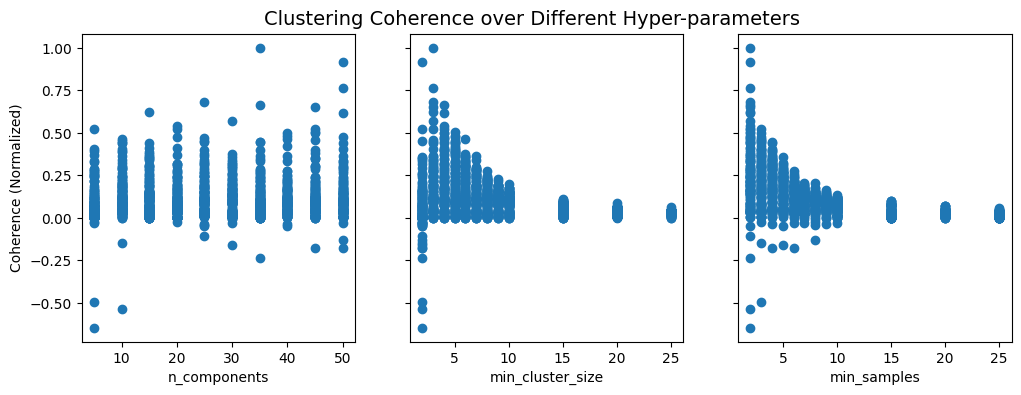

In [48]:
fig, axs = plt.subplots(1, 3, sharey=True,
                       figsize=(12, 4))

fig.suptitle('Clustering Coherence over Different Hyper-parameters', 
             fontsize=14, y=0.94)


#axs[0].scatter(range(len(hypes)), y)
#axs[0].set_xlabel('All combinations')
#axs[0, 0].set_ylabel('Coherence (Normalized)')

axs[0].scatter(n_comps, y)
axs[0].set_xlabel('n_components')
axs[0].set_ylabel('Coherence (Normalized)')


axs[1].scatter(min_clusts, y)
axs[1].set_xlabel('min_cluster_size')

axs[2].scatter(min_samps, y)
axs[2].set_xlabel('min_samples')


plt.savefig('figs/sm_coherence.png', dpi=300)
plt.show()


In [14]:
# write to file
with open('data/parameter_sweep/hypes_sweep.txt', 'w') as fp:
    for hype in hypes:
        fp.write(','.join([str(val) for val in hype]) + '\n')
        
with open('data/parameter_sweep/scores_sweep.txt', 'w') as fp:
    for score in scores:
        fp.write(','.join([str(val) for val in score]) + '\n')

# Examine cluster stability across different parameters

In [15]:
def var_of_info(bench, clusts):
    # Calculates VI(X, Y) = H(X) + H(Y) - 2I(X, Y)"""
    
    # Calculate Mutual Information
    mi = mutual_info_score(bench, clusts)
    
    # Calculate Entropy
    h1 = mutual_info_score(bench, bench)
    h2 = mutual_info_score(clusts, clusts)
    
    # VI = H(X) + H(Y) - 2I(X, Y)
    vi = h1 + h2 - 2 * mi
    return vi

In [17]:
def get_clusters(cluster_labels):
    # {num : [words]} 
    clust_words = dict() 

    for word, label in zip(kept, cluster_labels):
        clust_words.setdefault(label, set())
        clust_words[label].add(word)
        
    return clust_words

In [22]:
def check_seed(kept, word_embeddings, bench, best):    
    
    # hyperparameters - same as benchmark data
    n_components = best[0] 
    min_cluster_size = best[1]
    min_samples = best[2]

    seeds = list()
    sims = list()
    coherence = list()
    
    for seed in range(100, 251):
        cluster_labels = run_clustering(n_components, min_cluster_size, 
                                        min_samples, word_embeddings, seed)
        
        # get variation of information
        VI = var_of_info(cluster_bench, cluster_labels)
        
        sims.append(VI)
        
        # get coherence scores
        coherence_scores = calc_coherence(kept, word_embeddings, cluster_labels)
        coherence.append(coherence_scores)
        
        # count number of clusters. Note: words assigned to "-1" (no cluster) retained as unique words
        n_clusters = list(cluster_labels).count(-1) + max(cluster_labels) + 1 # 0-indexed

        # save hyper parameters and number of clusters
        hypes.append([seed, n_clusters])

    return seeds, sims, coherence

In [23]:
# benchmark clusters -- compare all other clusters to those used in manuscript

# get hyperparameters for best coherence score
idx = np.where(np.array(y) == max(y))[0]
best = hypes[idx[0]]

# hyperparameters
n_components = best[0] 
min_cluster_size = best[1]
min_samples = best[2]

print(f'Benmarking with n_components={n_components}, min_cluster_size={min_cluster_size}, min_samples={min_samples}')
cluster_bench = run_clustering(n_components, min_cluster_size, min_samples, word_embeddings)   
bench = get_clusters(cluster_bench)

Benmarking with n_components=35, min_cluster_size=3, min_samples=2


In [24]:
seeds, sims, coherence = check_seed(kept, word_embeddings, bench, best)

In [25]:
# write to file
with open('data/parameter_sweep/hypes_seed.txt', 'w') as fp:
    for hype in hypes:
        fp.write(','.join([str(val) for val in hype]) + '\n')

with open('data/parameter_sweep/similarities_seed.txt', 'w') as fp:
    for VI in sims:
        fp.write(f'{VI}\n')

with open('data/parameter_sweep/scores_seed.txt', 'w') as fp:
    for score in coherence:
        fp.write(f'{score}\n')

In [37]:
#### Null model
# record VI
null_scores = list()
null=cluster_bench.copy()

for i in range(100):
    # shuffle the benchmark labels
    np.random.shuffle(null)
    VI = var_of_info(cluster_bench, null)
    
    null_scores.append(VI)

In [28]:
# Observed data
print(np.mean(sims))
print(np.std(sims))

2.2950959208760446
0.05160603181031105


In [38]:
# null model 
print(np.mean(null_scores))
print(np.std(null_scores))

5.095116101560388
0.027797064563783176


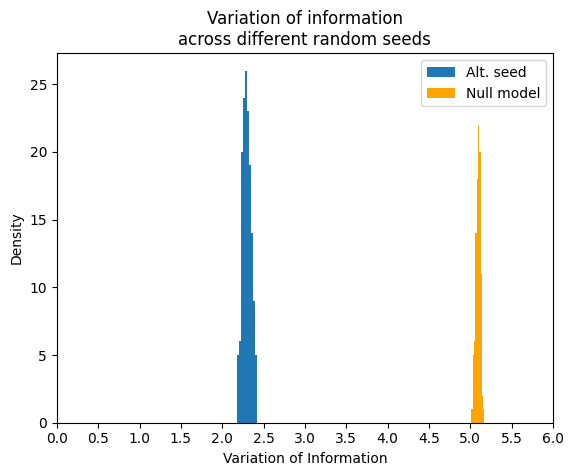

In [41]:
plt.hist(sims, label='Alt. seed')
plt.hist(null_scores, color='orange', label='Null model')
plt.xticks(np.arange(0, 6.5, .5))
plt.xlabel('Variation of Information')
plt.ylabel('Density')
plt.legend(bbox_to_anchor=(1,1))
plt.title('Variation of information\nacross different random seeds')
plt.savefig('figs/sm_VI.png', dpi=300, bbox_inches='tight')
plt.show()

# Manual evaluation of benchmark model

In [51]:
# count number of clusters (0-indexed). 
# Note: words assigned to "-1" (no cluster) retained as unique words
n_clusters = len(bench[-1]) + max(bench) + 1

print(f'{n_clusters} clusters found') 
print(f'{len(bench[-1])} clusters represented by a single word')
print(f'{max(bench) + 1} concepts represented by 2+ words')

2149 clusters found
1690 clusters represented by a single word
459 concepts represented by 2+ words


In [55]:
for word in bench[2]:
    print(word)

divided
splitting
separation
divide
breakup
split


In [57]:
for word in bench[4]:
    print(word)

combat
struggle
battle
fight
fighting
fighter


In [58]:
for word in bench[9]:
    print(word)

billionaire
millionaire
entrepreneur
businessman
baron
salesman


In [63]:
for word in bench[14]:
    print(word)

trash
garbage
waste
litter


In [66]:
for word in bench[234]:
    print(word)

news
media
newspaper
press
magazine
journalism


In [72]:
for word in bench[345]:
    print(word)

image
portrait
photo
picture


In [79]:
# write to file
import json

with open('data/word_clusters.json', 'w') as fp:
    fp.write(json.dumps(dict((str(i), list(vals)) for i, vals in bench.items())))